In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [18]:
#Load crap
GEN_PATH = "../../assets/02/gen/"
img = cv2.imread("../../assets/02/FF_XIII_src.jpg")

#Process all. GrayScale, Blur (Gaussian), Sharpenning, Sobel, Laplace

#Grayscale conversion
img_gs = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

cv2.imwrite(f"{GEN_PATH}grayscale.png", img_gs)

#Gaussian Blur and GrayScale. Doesn't fuck up the colors. Used in the next processing steps. Noise Reduction.
img_gsblur = cv2.GaussianBlur(img_gs, (5, 5), 0)

cv2.imwrite(f"{GEN_PATH}gsgaussian_blur.png", img_gsblur)

#Sharpen. 
#Sharpening Kernel.
sp_ker = np.array([
                    [0, -1, 0],
                    [-1, 5, -1],
                    [0, -1, 0]
                 ])
img_sp = cv2.filter2D(img_gs, -1, sp_ker)

cv2.imwrite(f"{GEN_PATH}sharpen.png", img_sp)

#Edge Detection.

#Sobel X & Y gradients
img_grad_sobx = cv2.Sobel(img_gsblur, cv2.CV_64F, 1, 0, ksize = 5) 
img_grad_soby = cv2.Sobel(img_gsblur, cv2.CV_64F, 0, 1, ksize = 5) 

abs_sobx = cv2.convertScaleAbs(img_grad_sobx)
abs_soby = cv2.convertScaleAbs(img_grad_soby)

img_sobel = cv2.addWeighted(abs_sobx, 0.5, abs_soby, 0.5, 0)

cv2.imwrite(f"{GEN_PATH}sobelx.png", abs_sobx)
cv2.imwrite(f"{GEN_PATH}sobely.png", abs_soby)
cv2.imwrite(f"{GEN_PATH}sobel.png", img_sobel)

#Laplacian. Uses Blurred and Grayscale image to reduce noise.

img_grad_lapl = cv2.Laplacian(img_gsblur, cv2.CV_64F, ksize = 5)

img_lapl = cv2.convertScaleAbs(img_grad_lapl)

cv2.imwrite(f"{GEN_PATH}laplacian.png", img_lapl)

True

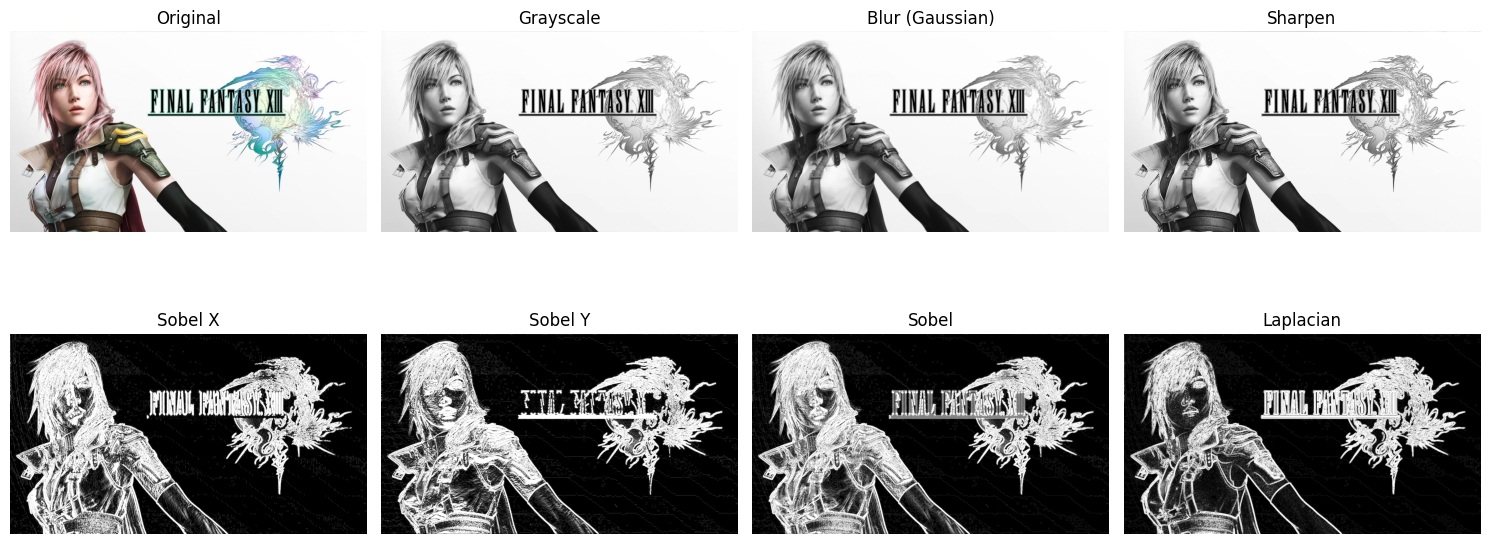

In [19]:
#Show comparison, generate img comparison in asstes/02/

#src image in bgr-rgb conversion
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_layout = [
                img_rgb, img_gs, img_gsblur, img_sp,
                abs_sobx, abs_soby, img_sobel, img_lapl 
             ]

t_type = [
            "Original", "Grayscale", "Blur (Gaussian)", "Sharpen",
            "Sobel X", "Sobel Y", "Sobel", "Laplacian"
    
         ]

fig, axes = plt.subplots(2, 4, figsize = (15, 7))
ax = axes.ravel()

for i, (img, t) in enumerate(zip(img_layout, t_type)):
    cmap = "gray"
    if i == 0:
        cmap = None
        
    ax[i].imshow(img, cmap)
    ax[i].set_title(t)
    ax[i].axis("off")

plt.tight_layout()

plt.savefig(f"{GEN_PATH}comparison.png")

plt.show()